# EDA


In [31]:
# System Libraries
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

# Added libraries and modules
from diagnostics import diagnose_data
import pandas as pd
import matplotlib.pyplot as plt
from kaggle_interaction.load import load_data
pd.set_option('display.max_columns', 54)

In [3]:
# Load data
train_set, test_set = load_data()

## Data shape and table


In [4]:
n_rows = 5
display(train_set.head(n_rows))
display(test_set.head(n_rows))
print('train_set shape:', train_set.shape)
print('test_set shape:', test_set.shape)

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff
0,1,2013-02-02 15:27:40,24,216,NaN,NaN,219,3180,3,4.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-02-02 15:27:40,24,216,NaN,NaN,219,5543,3,4.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2013-02-02 15:27:40,24,216,NaN,NaN,219,14142,2,3.5,...,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2013-02-02 15:27:40,24,216,NaN,NaN,219,22393,3,4.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2013-02-02 15:27:40,24,216,NaN,NaN,219,24194,3,4.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


train_set shape: (4958347, 54)
test_set shape: (4959183, 50)


In [5]:
display("All attributes in training set: ", train_set.columns)
train_excl_attr = set(train_set.columns) - set(test_set.columns)
display("training exclusive attributes: ", train_excl_attr)

'All attributes in training set: '

Index(['srch_id', 'date_time', 'site_id', 'visitor_location_country_id',
       'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id',
       'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool',
       'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window',
       'srch_adults_count', 'srch_children_count', 'srch_room_count',
       'srch_saturday_night_bool', 'srch_query_affinity_score',
       'orig_destination_distance', 'random_bool', 'comp1_rate', 'comp1_inv',
       'comp1_rate_percent_diff', 'comp2_rate', 'comp2_inv',
       'comp2_rate_percent_diff', 'comp3_rate', 'comp3_inv',
       'comp3_rate_percent_diff', 'comp4_rate', 'comp4_inv',
       'comp4_rate_percent_diff', 'comp5_rate', 'comp5_inv',
       'comp5_rate_percent_diff', 'comp6_rate', 'comp6_inv',
       'comp6_rate_percent_diff', 'comp7_rate'

'training exclusive attributes: '

{'booking_bool', 'click_bool', 'gross_bookings_usd', 'position'}

The above show the following:
- Both the training and test sets have close to 5 million instances.
- Training set has 54 attributes, test set has 50
- The training exclusive attributes are:
    - Booking_bool, click_bool, gross_bookings_usd, position

## Evaluation Goal
The evaluation is given in the assignment document under "Winning the competition". The evaluation metric is NDCG@5 (Normalized Discounted Cumulative Gain). The @5 designates that they will look at ranks 1-5 in each search query. 

Each query contains a set of hotels. The hotels are assigned following values:
- 5 = the user purchased a room
- 1 = the user clicked through to see more information on this hotel
- 0 = the user did neither

For each hotel in the training set, this value can be derived from "booking_bool" and "click_bool"

The NDCG@5 takes the top 5 ranked hotels in our prediction and computes the sum of their "relevance scores" (the values above). It then applies penalization for highly relevant hotels having lower ranks (e.g. if the hotel booked is ranked 5th), and normalizes the score against varying number of hotel listings per search. 
The average across all queries in the test set is taken to determine the performance of our model in the competition. 

##### Questions/Notes:
- The evaluation metric they use is on the query-level and not the hotel-level. So each query could be seen as a training instance itself. So we could engineer non-parametric transformations into ranks or z-standardizations of the original features which makes the listings more comparable across queries. For example, a query with big budget vs one with low budget, the absolute price of the hotels doesn't matter to the user, only the price relative to all other hotels. 
- While this is the competition evaluation, we can train models using different evaluation (hotels that were booked or clicked have value 1, then it can be a logistic regression model). There is also a model which uses this specific evaluation metric as loss: LambdaMART (https://www.shaped.ai/blog/lambdamart-explained-the-workhorse-of-learning-to-rank) 
    - One team who participated in this competition used the following models (https://arxiv.org/pdf/1311.7679): 
        - LIBLINEAR and SVMRankfor pairwise logistic regression; 
        - Random Forest from scikit-learn 
        - Ranking algorithms like AdaRank, LambdaMART from RankLib2. 
        - Gradient Boosting Machine3, Extremely Randomized Trees4 from R, 
        - deep neural network implementation from PyLearn2
        - Factorization Machine libFM5
    - LamgdaMART is computationally intensive to train, relies on good feature engineering, and is sensitive to hyperparameters D:)


## Sparsity

In [26]:
sparsity = sum((train_set == 0).astype(int).sum())/train_set.size
print('sparsity of train_set:', sparsity)
diagnose_data(train_set, name = 'train_set')
display(train_set.isna().sum())

sparsity of train_set: 0.1707275758708222
+++ Data Diagnostics +++
Diagnostics for train_set:
pandas DataFrame 
Shape: (4958347, 55)
Number of Missing Values: 119733280
Percentage of Missing Values: 43.91%
++++++++++++++++++++++++




srch_id                              0
date_time                            0
site_id                              0
visitor_location_country_id          0
visitor_hist_starrating        4706481
visitor_hist_adr_usd           4705359
prop_country_id                      0
prop_id                              0
prop_starrating                      0
prop_review_score                 7364
prop_brand_bool                      0
prop_location_score1                 0
prop_location_score2           1090348
prop_log_historical_price            0
position                             0
price_usd                            0
promotion_flag                       0
srch_destination_id                  0
srch_length_of_stay                  0
srch_booking_window                  0
srch_adults_count                    0
srch_children_count                  0
srch_room_count                      0
srch_saturday_night_bool             0
srch_query_affinity_score      4640941
orig_destination_distance

- The training set is not particularly sparse
- However, close to half of the data has missing values, which is a problem.
- It's likely that this is systematic missingness: Looking at the first 5 entries of both sets, missingness seems to be pervasive within specific variables:
    - "visitor_hist_starrating", "visitor_hist_adr_usd" : Nulls mean that there is no user history for purchases -> Many customers are new customers. Imputation here could be a neutral value, for example neutral rating and mean average purchase history.
    - "srch_query_affinity_score" : Null means that hotel did not register in searches -> Many hotels did not register in search queries.
    - "orig_destination_distance" : Null means that distance could not be calculated. -> This is potentially a useful attribute, some imputation heuristic could be useful here. For example, we could use "visitor_location_country_id" and compute the distance to the property. 
    - "comp* attributes" : Null means there is no competetive data -> There is no competetive data of certain competitors for certain hotels listed. Question here is what it means that there is no data? Either data is missing at random (measurement error) or competitor x does not have the property in their catalogue, hence no competetive data. The definition of "availability" in the attribute description is not clear: Does no availability mean they have the property, but there are no rooms available, or they do not have the property?

## 

The evaluation metric requires at least 5 listings per search. Also, the attributes "click_bool" and "booking_bool" ideally do not need imputation. To know if this holds:

In [7]:
train_grouped = train_set.groupby('srch_id')
n_search = list() 

for srch_id, data in train_grouped:
    n_search.append(data.shape[0])

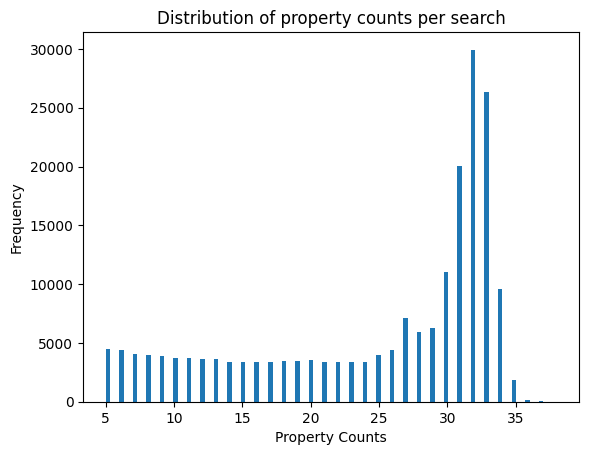

In [8]:
plt.hist(n_search, bins = 100)
plt.title('Distribution of property counts per search')
plt.xlabel('Property Counts')
plt.ylabel('Frequency')
plt.show()

In [9]:
train_set[['booking_bool', 'click_bool']].isna().sum()

booking_bool    0
click_bool      0
dtype: int64

Thankfully all searches seem to have resulted in at least 5 properties, the evaluation metric is applicable. Thankfully the attributes that the evaluate metric depends on have no missing values, hence we do not need to impute those.

## Number of queries

We have almost 200 000 searches in the training set, likewise in the test set. 

In [10]:
query_count_train = train_set['srch_id'].unique().size
display('Number of search queries in the training set: ', query_count_train)

'Number of search queries in the training set: '

199795

## Univariate Analysis

### Target variable: Relevance
The evaluation target is the NDCG per query, which requires relevance scores per hotel in a query. We need to engineer a feature called "rel_score" from "click_bool" and "booking_bool":

In [11]:
which_clicked = train_set.query('click_bool == 1').index
which_booked = train_set.query('booking_bool == 1').index
which_neither = train_set.query('click_bool == 0 & booking_bool == 0').index

train_set.loc[which_clicked, 'rel_score'] = 1
train_set.loc[which_booked, 'rel_score'] = 5
train_set.loc[which_neither, 'rel_score'] = 0

display(train_set[['booking_bool', 'click_bool', 'rel_score']].head())
display(train_set[['booking_bool', 'click_bool', 'rel_score']].query('rel_score != 0.0').head())

,booking_bool,click_bool,rel_score
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0


,booking_bool,click_bool,rel_score
12,1,1,5.0
59,0,1,1.0
63,1,1,5.0
68,1,1,5.0
90,0,1,1.0


When looking at relevance scores within individual search queries, we find that there are some (or many) queries where the user just clicks on one listing and then immediately books it. There are also queries where the user clicked on some listings, but does not book anything. 

Furthermore, 

So there are queries for which the maximal sum of relevance scores is 5: If the one booked is in the top 5 in your model's ranking, then you get the best possible evaluation by NDCG

In [54]:
display(train_set.loc[which_clicked].query('srch_id == 1')) # clicked one and booked
display(train_set.loc[which_clicked].query('srch_id == 4')) # clicked one and didn't book anything

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,...,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,rel_score,checkin_date
12,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,68914,2,3.0,1,2.2,0.0206,4.44,13,100.89,0,23246,1,0,4,0,1,1,NaN,NaN,1,...,NaN,0.0,0.0,11.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,11.0,1,114.29,1,5.0,2013-04-04 08:32:15


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,prop_location_score2,prop_log_historical_price,position,price_usd,promotion_flag,srch_destination_id,srch_length_of_stay,srch_booking_window,srch_adults_count,srch_children_count,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,...,comp1_rate_percent_diff,comp2_rate,comp2_inv,comp2_rate_percent_diff,comp3_rate,comp3_inv,comp3_rate_percent_diff,comp4_rate,comp4_inv,comp4_rate_percent_diff,comp5_rate,comp5_inv,comp5_rate_percent_diff,comp6_rate,comp6_inv,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool,rel_score,checkin_date
59,4,2012-12-31 08:59:22,5,219,NaN,NaN,219,139893,2,3.0,1,1.61,0.0309,5.25,16,129.0,0,12588,2,46,1,0,1,1,NaN,236.14,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,0,1.0,2013-02-15 08:59:22


In [13]:
# Every query has 1 booked property!
display('number of queries where nothing was booked', train_set.groupby('srch_id').max().query('booking_bool == 0').shape[0])
display('number of queries where nothing was clicked',train_set.groupby('srch_id').max().query('click_bool == 0').shape[0])

'number of queries where nothing was booked'

61405

'number of queries where nothing was clicked'

0

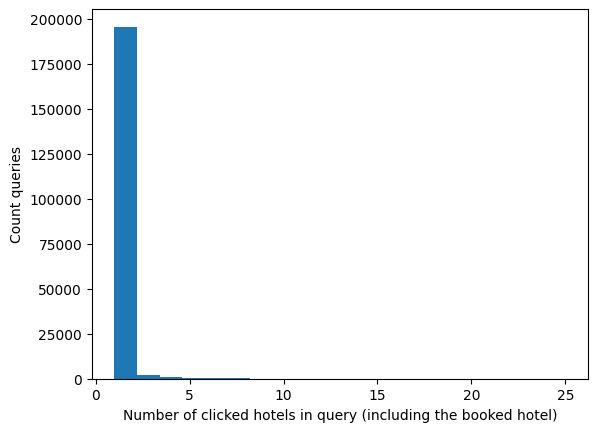

number of queries with 1 click only:  186764


In [56]:
# Plot the number of clicked hotels for all queries
clicked_counts = train_set.loc[which_clicked].groupby('srch_id').size()
plt.hist(clicked_counts, bins = 20)
plt.xlabel('Number of clicked hotels in query (including the booked hotel)')
plt.ylabel('Count queries')
plt.show()
single_click_query_count = (clicked_counts == 1).sum()
print('number of queries with 1 click only: ', single_click_query_count)


- There are 61405 queries which did not result in any booking
- There are no queries that did not result in a click
- The number of queries where there was only one click **by far outweight queries with more than one click**

From all queries that had one single click, how many resulted in that clicked hotel being booked?

In [15]:
train_set_no_datetime = train_set.drop(columns=['date_time'])
queries_one_click_no_book = train_set_no_datetime.groupby('srch_id').sum().query('click_bool == 1 & booking_bool == 0')
queries_one_click = train_set_no_datetime.groupby('srch_id').sum().query('click_bool == 1')

print('ratio of queries with one click to queries with more than one click: ',
      single_click_query_count / query_count_train)
print('ratio of queries with no booking within queries with only one click: ',
      queries_one_click_no_book.shape[0] / queries_one_click.shape[0])

ratio of queries with one click to queries with more than one click:  0.9347781476012913
ratio of queries with no booking within queries with only one click:  0.30458225353922597


**Conclusion**: Around 93% of the queries in the training data are single-click queries. And there are around 70% of these where the single click resulted in that hotel being booked. This means that around 65% of total queries will have only one hotel which was consequently clicked on and booked.  

What consequences does this have for the modelling? The output below illustrates this: If there is only a single non-zero relevance value in the top-5 (either 1 or 5), then the NDCG penalizes this more than if there are other non-zero values. Also, if there is only one non-single value, then it doesn't matter to the NDCG if it is 1 or 5. 

Since single-click/book queries are 93% of the total queries, this means that our model should be focusing on learning to put relatively high relevance scores on top as much as possible, and the penalty for putting higher relevance scores in lower ranks should be very high for the model to learn to do so. We could adjust the relevance scores for training, or adjust the NDCG formula to do so. 

In [16]:
from evaluation.metrics import ndcg_5

one_click_ranked_scores = [5, 0, 0, 0, 0]
five_click_ranked_scores = [5, 1, 1, 1, 1]
one_click_no_book_ranked_scores = [5, 0, 0, 0, 0]
print('Best possible scores')
print('one_click_booked: ', ndcg_5(one_click_ranked_scores))
print('five_clicks: ', ndcg_5(five_click_ranked_scores))
print('one_click_not_booked: ', ndcg_5(one_click_no_book_ranked_scores))
print('==========')

one_click_ranked_scores = [0, 5, 0, 0, 0]
five_click_ranked_scores = [1, 5, 1, 1, 1]
one_click_no_book_ranked_scores = [0, 1, 0, 0, 0]
print('Second best possible scores')
print('one_click_booked: ', ndcg_5(one_click_ranked_scores))
print('five_clicks: ', ndcg_5(five_click_ranked_scores))
print('one_click_not_booked: ', ndcg_5(one_click_no_book_ranked_scores))
print('==========')

one_click_ranked_scores = [0, 0, 5, 0, 0]
five_click_ranked_scores = [1, 1, 5, 1, 1]
one_click_no_book_ranked_scores = [0, 0, 5, 0, 0]
print('Third best possible scores')
print('one_click_booked: ', ndcg_5(one_click_ranked_scores))
print('five_clicks: ', ndcg_5(five_click_ranked_scores))
print('one_click_not_booked: ', ndcg_5(one_click_no_book_ranked_scores))
print('==========')

Best possible scores
one_click_booked:  1.0
five_clicks:  1.0
one_click_not_booked:  1.0
Second best possible scores
one_click_booked:  0.6309297535714575
five_clicks:  0.7875383649156079
one_click_not_booked:  0.6309297535714575
Third best possible scores
one_click_booked:  0.5
five_clicks:  0.7121664003799236
one_click_not_booked:  0.5


### Other variables
#### Datetime
The date_times of the query are distributed within a range of around half a year: From November 2012 to June 2013. The distribution of query datetimes seems to show an increase in searches as summer comes along. The number of bookings alse increase as summer approaches. 

earliest search date:  2012-11-01 00:08:29
latest search date:  2013-06-30 23:58:24


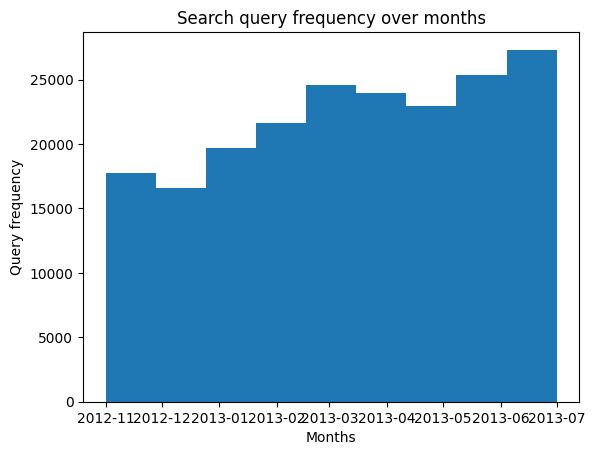

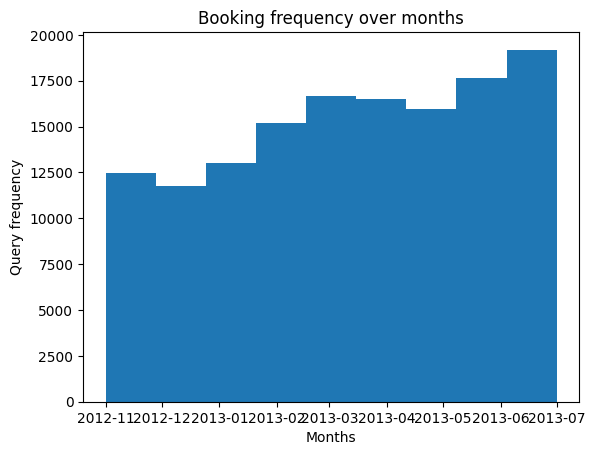

In [50]:
range_date_time = (train_set['date_time'].min(), train_set['date_time'].max())
print("earliest search date: ", range_date_time[0])
print("latest search date: ", range_date_time[1])

query_times = train_set.groupby('srch_id')['date_time'].first()
plt.hist(query_times, bins = 9)
plt.title('Search query frequency over months')
plt.ylabel('Query frequency')
plt.xlabel('Months')
plt.show()

booking_times = train_set.loc[which_booked].groupby('srch_id')['date_time'].first()
plt.hist(booking_times, bins = 9)
plt.title('Booking frequency over months')
plt.ylabel('Query frequency')
plt.xlabel('Months')
plt.show()

We might be interested in the intended date when the hotel stay should start (this could also be a feature as otherwise the model must learn this from "date_time" and "srch_booking_window").

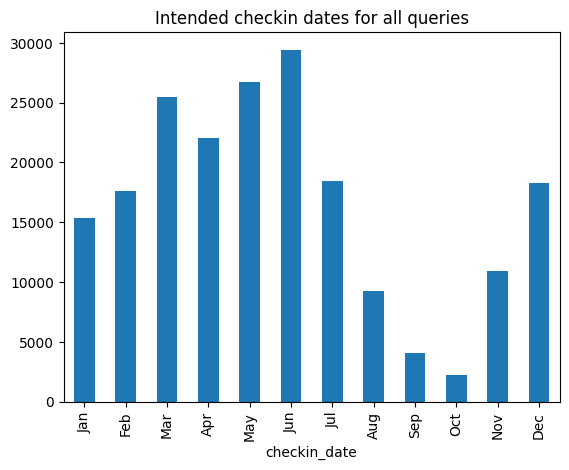

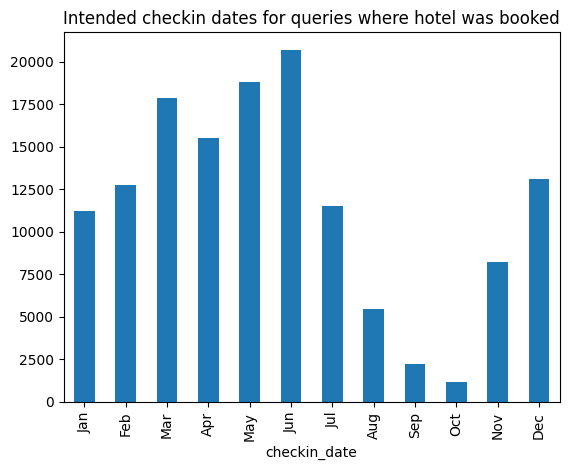

In [53]:
train_set['checkin_date'] = train_set['date_time'] + pd.to_timedelta(train_set['srch_booking_window'], unit='D')
counts = train_set.groupby('srch_id')['checkin_date'].first().dt.month.value_counts().sort_index()
counts = counts.reindex(range(1, 13), fill_value=0)
counts.plot(kind='bar')
plt.title("Intended checkin dates for all queries")
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

counts = train_set.query('booking_bool == 1').groupby('srch_id')['checkin_date'].first().dt.month.value_counts().sort_index()
counts = counts.reindex(range(1, 13), fill_value=0)
counts.plot(kind='bar')
plt.title('Intended checkin dates for queries where hotel was booked')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

There is a clear trend: There are off-seasons where desired checkins are low (Aug-Nov) and high seasons (Dec-July) where intended checkins are high. The same applies for queries where a booking was confirmed. We might benifit from creating a categorical variable which encodes whether the intended check-in date occurs in a high season.  

## Multivariate analysis
